In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [7]:
df = pd.read_csv('/content/house (1) (1) (1).csv')
print(df.head())


    price  area_sqft  bedrooms  bathrooms  year_built   location  \
0  320000       1450         3        2.0        1998   SouthEnd   
1  455000       1870         4        2.5        2005  NorthDale   
2  285000       1210         2        1.0        1975  WestVilla   
3  510000       2100         3        2.5        2010    OakView   
4  720000       2800         4        3.5        2015  RiverSide   

   distance_to_city_center  has_garage  has_pool  condition  crime_rate  \
0                      5.2           1         0          3         8.7   
1                      3.6           1         0          4         3.2   
2                      7.8           1         0          2        12.5   
3                      2.9           1         0          4         2.8   
4                      2.1           1         1          5         1.5   

   school_rating  
0              6  
1              8  
2              4  
3              9  
4              9  


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   price                    40 non-null     int64  
 1   area_sqft                40 non-null     int64  
 2   bedrooms                 40 non-null     int64  
 3   bathrooms                40 non-null     float64
 4   year_built               40 non-null     int64  
 5   location                 40 non-null     object 
 6   distance_to_city_center  40 non-null     float64
 7   has_garage               40 non-null     int64  
 8   has_pool                 40 non-null     int64  
 9   condition                40 non-null     int64  
 10  crime_rate               40 non-null     float64
 11  school_rating            40 non-null     int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 3.9+ KB
None


In [9]:
print(df.isnull().sum())

price                      0
area_sqft                  0
bedrooms                   0
bathrooms                  0
year_built                 0
location                   0
distance_to_city_center    0
has_garage                 0
has_pool                   0
condition                  0
crime_rate                 0
school_rating              0
dtype: int64


In [10]:
df = df.fillna(df.median(numeric_only=True))
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
df = pd.get_dummies(df, drop_first=True)


               price    area_sqft   bedrooms  bathrooms   year_built  \
count      40.000000    40.000000  40.000000  40.000000    40.000000   
mean   506150.000000  1993.750000   3.375000   2.400000  2001.750000   
std    206944.629037   675.386641   0.837808   0.885785    15.227758   
min    245000.000000   980.000000   2.000000   1.000000  1965.000000   
25%    318750.000000  1410.000000   3.000000   1.875000  1994.250000   
50%    470000.000000  1895.000000   3.000000   2.500000  2007.000000   
75%    660000.000000  2412.500000   4.000000   3.000000  2012.250000   
max    940000.000000  3450.000000   5.000000   4.000000  2020.000000   

       distance_to_city_center  has_garage   has_pool  condition  crime_rate  \
count                40.000000   40.000000  40.000000  40.000000   40.000000   
mean                  4.252500    0.925000   0.325000   3.675000    5.597500   
std                   2.214056    0.266747   0.474342   0.971055    4.187496   
min                   0.800000 

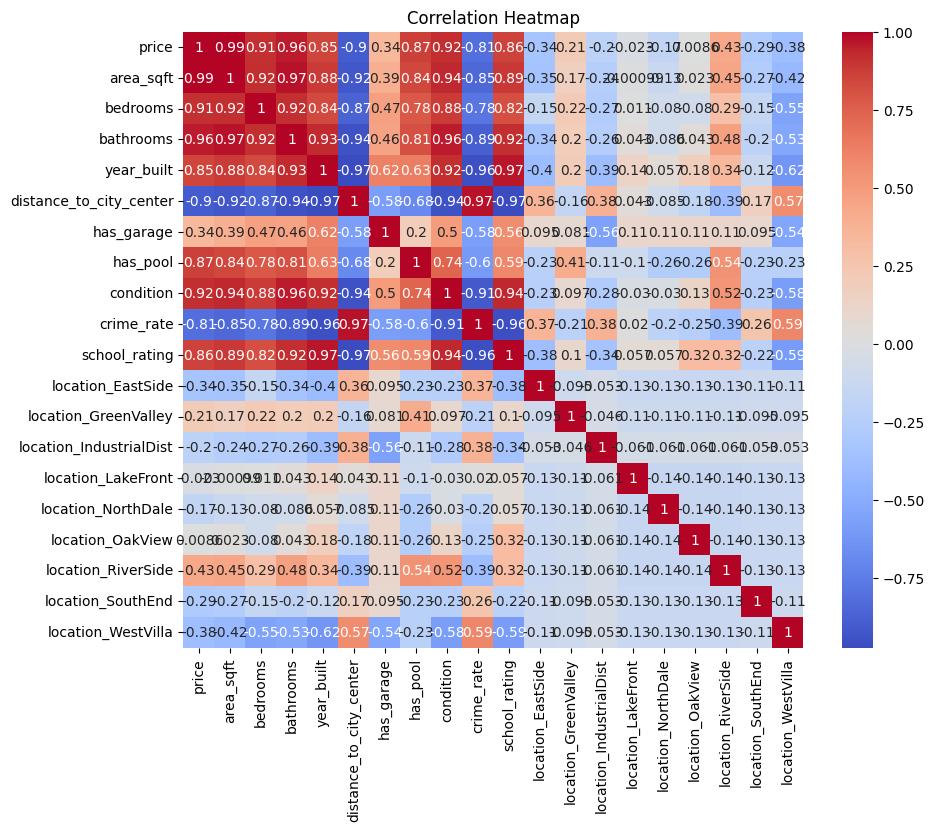

In [11]:

print(df.describe())
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [14]:
X = df.drop('price', axis=1)
y = df['price']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [17]:
y_pred = model.predict(X_test)


In [18]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Model Evaluation:
MAE: 33468.58
MSE: 1349945283.19
RMSE: 36741.60
R² Score: 0.96


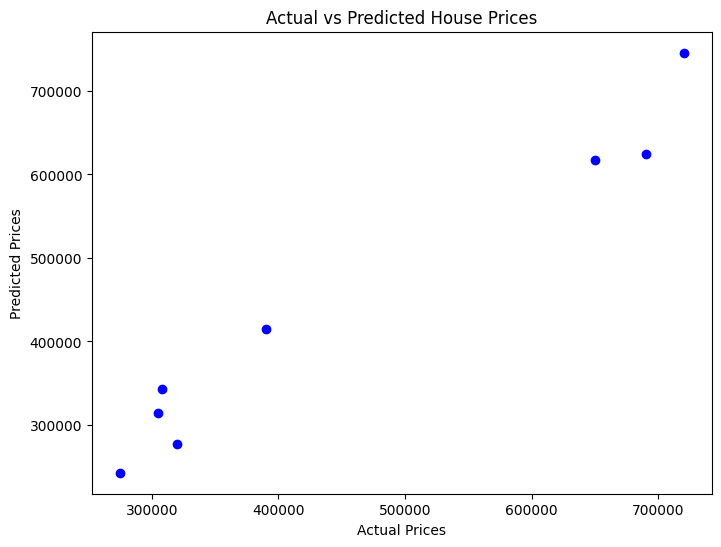

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()


In [20]:
import joblib
joblib.dump(model, "house_price_model.pkl")


['house_price_model.pkl']